# Recurrent Neural Network (RNN)

Dataset:
IMDb Movie Reviews

Task:
Binary Classification

Positive Review → 1

Negative Review → 0

In [15]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt
import numpy as np

In [16]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

In [17]:
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

print("\nFirst Review:")
print(X_train[0])

print("\nLabel:")
print(y_train[0])

Training Samples: 25000
Testing Samples: 25000

First Review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32

#Pad Sequences

In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding='post')

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding='post')

Reviews have different lengths.

Review A

15 words

Review B

250 words

Review C

120 words

Padding makes all reviews exactly 200 words long.

In [19]:
print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


#Build the RNN Model

In [20]:
model = Sequential()

model.add(Embedding(input_dim=vocab_size,
                    output_dim=32,
                    input_length=max_length))

model.add(SimpleRNN(32))

model.add(Dense(1,
                activation='sigmoid'))

#Embedding Layer
Word

↓

Dense Vector

↓

[0.21 0.15 0.84 ...]

Word 1

↓

Word 2

↓

Word 3

↓

...

It remembers previous words while reading new ones.

I

↓

love

↓

this

↓

movie

#Dense Layer
Sigmoid Output

0.95

↓

Positive

0.08

↓

Negative

#Compile Model

In [21]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#Train the Model

In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.5232 - loss: 0.6882 - val_accuracy: 0.5426 - val_loss: 0.6784
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.6305 - loss: 0.6119 - val_accuracy: 0.5728 - val_loss: 0.6696
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.7078 - loss: 0.4822 - val_accuracy: 0.5424 - val_loss: 0.7254
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.7473 - loss: 0.4080 - val_accuracy: 0.5340 - val_loss: 0.8705
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.7812 - loss: 0.3577 - val_accuracy: 0.5346 - val_loss: 0.9587


#Training process
Input Review

↓

Prediction

↓

Compare with Actual Label

↓

Calculate Error

↓

Update Weights

↓

Repeat

#Evaluate Model

In [23]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5306 - loss: 0.9525
Test Loss : 0.9524542093276978
Test Accuracy : 0.5306400060653687


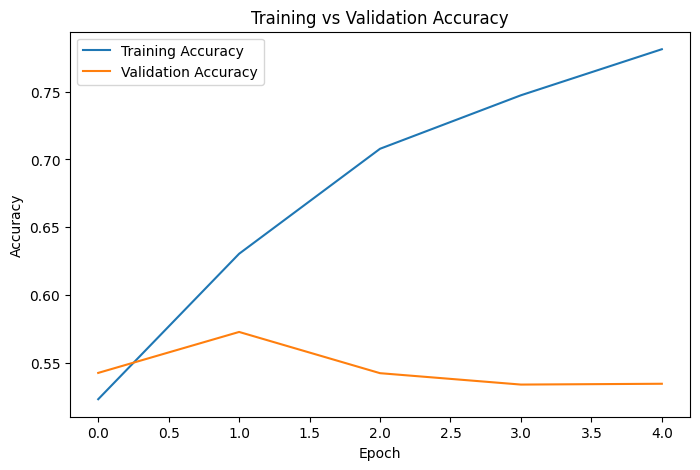

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

If both curves increase together, the model is learning well.

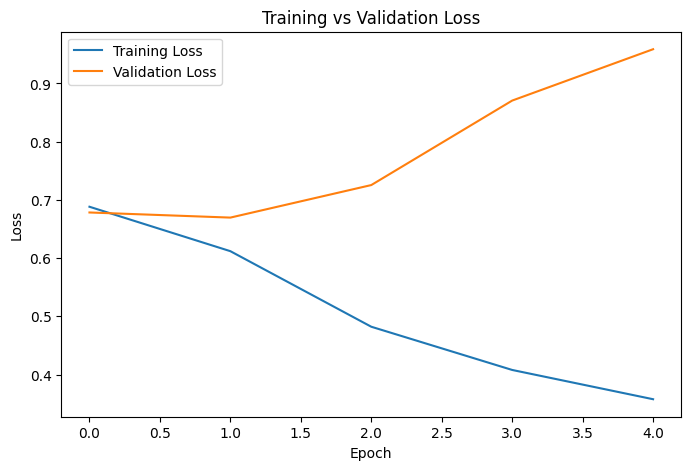

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

If Validation Loss starts increasing while Training Loss keeps decreasing, the model may be overfitting.

#Make Predictions

In [26]:
predictions = model.predict(X_test[:10])

for i, prediction in enumerate(predictions):
    print(f"Review {i+1}")

    print("Predicted Probability:", prediction[0])

    if prediction > 0.5:
        print("Predicted Sentiment: Positive")
    else:
        print("Predicted Sentiment: Negative")

    print("Actual Label:", y_test[i])
    print("-"*40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
Review 1
Predicted Probability: 0.46899945
Predicted Sentiment: Negative
Actual Label: 0
----------------------------------------
Review 2
Predicted Probability: 0.08738125
Predicted Sentiment: Negative
Actual Label: 1
----------------------------------------
Review 3
Predicted Probability: 0.014322401
Predicted Sentiment: Negative
Actual Label: 1
----------------------------------------
Review 4
Predicted Probability: 0.72904444
Predicted Sentiment: Positive
Actual Label: 0
----------------------------------------
Review 5
Predicted Probability: 0.6002088
Predicted Sentiment: Positive
Actual Label: 1
----------------------------------------
Review 6
Predicted Probability: 0.5161693
Predicted Sentiment: Positive
Actual Label: 1
----------------------------------------
Review 7
Predicted Probability: 0.046920653
Predicted Sentiment: Negative
Actual Label: 1
----------------------------------------
Review 8
Predicted Probability: 0.30197674
Predicte

The model outputs a probability between 0 and 1.

Probability > 0.5 → Positive Review

Probability ≤ 0.5 → Negative Review